# Loading Dataset 

In [ ]:
import pandas as pd

# Load the datasets 
department_df = pd.read_csv('data/departments.csv')
orders_df = pd.read_csv('data/orders.csv')
products_df = pd.read_csv('data/products.csv')
order_products_train_df = pd.read_csv('data/order_products__train.csv')
aisles_df = pd.read_csv('data/aisles.csv')

print("Datasets loaded successfully.")

Datasets loaded successfully.


# Preview Datasets 

In [10]:
print("departments_df")
display(department_df.head())

print("orders_df")
display(orders_df.head())

print("products_df")
display(products_df.head())

print("order_products_train_df")
display(order_products_train_df.head())

print("aisles_df")
display(aisles_df.head())

departments_df


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


orders_df


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


products_df


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


order_products_train_df


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


aisles_df


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


# Counting Snack Products 

In [11]:
# Total number of snack products
snack_department = 19
snack_count = (products_df['department_id'] == snack_department).sum()
print(snack_count)

6264


# Common Bought Snacks 

In [12]:
# Most commonly bought snacks
snack_products = products_df[products_df['department_id'] == snack_department]
snack_orders = order_products_train_df.merge(snack_products, on='product_id')
top_snacks = snack_orders['product_name'].value_counts().head(10)
print(top_snacks)

product_name
Lightly Salted Baked Snap Pea Crisps                   991
Pretzel Crisps Original Deli Style Pretzel Crackers    753
Sea Salt Pita Chips                                    707
Original Veggie Straws                                 684
Organic Tortilla Chips                                 637
Chocolate Chip Cookies                                 614
Sea Salt & Vinegar Potato Chips                        597
100 Calorie  Per Bag Popcorn                           552
Baked Aged White Cheddar Rice and Corn Puffs           546
Trail Mix                                              533
Name: count, dtype: int64


# Snack Products By Aisel 

In [13]:
# Snack products by aisle (counts)
snack_department = 19  # snacks department_id

snack_products = products_df[products_df["department_id"] == snack_department]

snack_products_with_aisles = snack_products.merge(aisles_df, on="aisle_id")

aisle_counts = snack_products_with_aisles["aisle"].value_counts().head(10)

print("Top 10 aisles with the most snack products:")
display(aisle_counts)

Top 10 aisles with the most snack products:


,count
aisle,
candy chocolate,1246
chips pretzels,989
cookies cakes,874
energy granola bars,832
crackers,747
nuts seeds dried fruit,582
fruit vegetable snacks,356
popcorn jerky,316
mint gum,168


# Visualization for Snack Aisles 

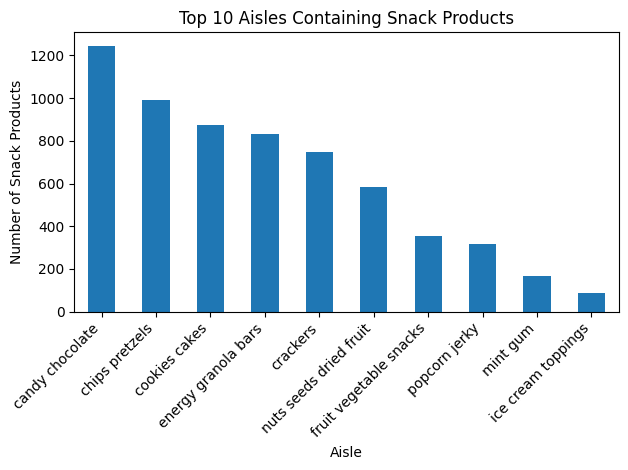

In [14]:
import matplotlib.pyplot as plt

aisle_counts.plot(kind="bar")

plt.title("Top 10 Aisles Containing Snack Products")
plt.xlabel("Aisle")
plt.ylabel("Number of Snack Products")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()